In [1]:
from pathlib import Path

from vascx.faz.retina import Retina
from vascx.utils.analysis import (
    extract_in_parallel,
)
from rtnls_enface.utils.data_loading import open_mask

## Vessel feature extraction

This notebook shows how to extract generic features using the FAZ retina class with a single binary mask and no additional segmentations available. This will extract a very generic set of features from any binary vessel segmentation. We use fundus images with only vessel segmenations as an example.

In [2]:
ds_path = Path('../../samples/fundus')

images_paths = sorted(list((ds_path / 'rgb').glob('*.png')))
vessels_paths = sorted(list((ds_path / 'vessels').glob('*.png')))

In [3]:
items = [{'id': im_path.stem, 'vessels_path': vessels_path, 'image_path': im_path} for im_path, vessels_path in zip(images_paths, vessels_paths)]

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

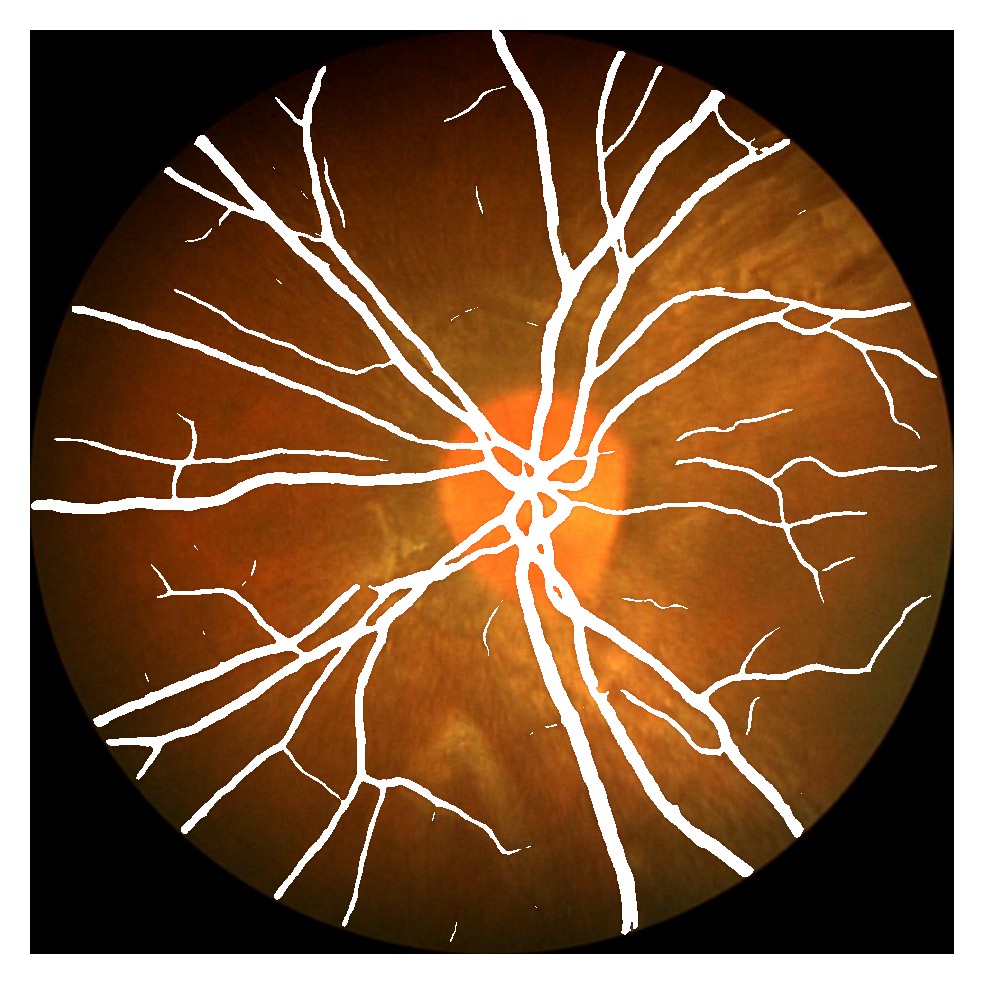

In [4]:
# to plot a retina
ret = Retina.from_file(**items[0])
ret.plot()

Now we extract the features using the `extract_in_parallel` utility.

In [5]:
extract_in_parallel(items, 'basic', retina_cls=Retina)

100%|██████████| 6/6 [00:00<00:00, 545.12it/s]
[Parallel(n_jobs=8)]: Done   2 out of   6 | elapsed:    4.8s remaining:    9.5s
[Parallel(n_jobs=8)]: Done   3 out of   6 | elapsed:    4.8s remaining:    4.8s
[Parallel(n_jobs=8)]: Done   4 out of   6 | elapsed:    4.9s remaining:    2.4s
[Parallel(n_jobs=8)]: Done   6 out of   6 | elapsed:    5.1s finished


,vd_vessels,diam_vessels_median,diam_vessels_std,tort_vessels,bif_vessels
CHASEDB1_08L,0.097878,7.669375,5.155146,1.017764,53
CHASEDB1_12R,0.098959,6.034774,6.052813,1.018441,54
DRIVE_22,0.067827,3.409004,3.073113,1.032860,73
DRIVE_40,0.080380,4.033925,3.571133,1.014318,67
HRF_04_g,0.049738,2.802983,2.364380,1.012686,67
HRF_07_dr,0.067895,3.016081,2.822721,1.018863,78


**Important**

Some of these features are scale-dependent and may need appropriate normalization for analysis.